# KNN Model

Train and evaluate a k-Nearest Neighbors classifier.

In [3]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import files
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
uploaded = files.upload()

Saving combined_hog_color_lbp.npz to combined_hog_color_lbp (1).npz
Saving label_mapping.pkl to label_mapping (1).pkl


In [8]:
from pathlib import Path
import joblib
import numpy as np

print("Current working folder:", Path.cwd())

# Search everywhere inside /content, including repository folders
npz_files = list(
    Path("/content").rglob("combined_hog_color_lbp*.npz")
)

mapping_files = list(
    Path("/content").rglob("label_mapping*.pkl")
)

print("\nFeature files found:")
for path in npz_files:
    print("-", path)

print("\nMapping files found:")
for path in mapping_files:
    print("-", path)

if not npz_files:
    raise FileNotFoundError(
        "combined_hog_color_lbp.npz was not found."
    )

if not mapping_files:
    raise FileNotFoundError(
        "label_mapping.pkl was not found."
    )

# Select the newest copies
combined_file = max(
    npz_files,
    key=lambda path: path.stat().st_mtime
)

mapping_file = max(
    mapping_files,
    key=lambda path: path.stat().st_mtime
)

feature_data = np.load(
    combined_file,
    allow_pickle=True
)

label_mapping = joblib.load(mapping_file)

print("\nUsing feature file:", combined_file)
print("Using mapping file:", mapping_file)
print("NPZ keys:", feature_data.files)
print("Number of class mappings:", len(label_mapping))

Current working folder: /content/Bird-Species-Classification-ML

Feature files found:
- /content/Bird-Species-Classification-ML/combined_hog_color_lbp.npz
- /content/Bird-Species-Classification-ML/combined_hog_color_lbp (1).npz

Mapping files found:
- /content/Bird-Species-Classification-ML/label_mapping (1).pkl
- /content/Bird-Species-Classification-ML/label_mapping.pkl

Using feature file: /content/Bird-Species-Classification-ML/combined_hog_color_lbp (1).npz
Using mapping file: /content/Bird-Species-Classification-ML/label_mapping (1).pkl
NPZ keys: ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']
Number of class mappings: 20


In [9]:
X_train = feature_data["X_train"]
y_train = feature_data["y_train"]

X_val = feature_data["X_val"]
y_val = feature_data["y_val"]

X_test = feature_data["X_test"]
y_test = feature_data["y_test"]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (780, 8206) (780,)
Validation: (167, 8206) (167,)
Testing: (168, 8206) (168,)


## Train a Baseline k-NN Classifier

The k-NN model is first trained using `k = 5`. Feature scaling is applied because k-NN classifies samples using distances between feature vectors.

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

print("k-NN libraries imported successfully.")


k-NN libraries imported successfully.


In [11]:
# Fit the scaler using only the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nFeature scaling completed successfully.")

Scaled training shape: (780, 8206)
Scaled validation shape: (167, 8206)
Scaled testing shape: (168, 8206)

Feature scaling completed successfully.


In [12]:
baseline_k = 5

baseline_knn = KNeighborsClassifier(
    n_neighbors=baseline_k,
    weights="uniform",
    metric="euclidean",
    n_jobs=-1
)

baseline_knn.fit(
    X_train_scaled,
    y_train
)

print("Baseline k-NN model trained successfully.")
print("Number of neighbors, k:", baseline_k)
print("Training samples:", len(y_train))

Baseline k-NN model trained successfully.
Number of neighbors, k: 5
Training samples: 780


In [13]:
baseline_val_predictions = baseline_knn.predict(
    X_val_scaled
)

baseline_val_accuracy = accuracy_score(
    y_val,
    baseline_val_predictions
)

correct_predictions = (
    baseline_val_predictions == y_val
).sum()

print("Validation images:", len(y_val))
print("Correct predictions:", correct_predictions)

print(
    f"Baseline validation accuracy with k={baseline_k}: "
    f"{baseline_val_accuracy:.4f}"
)

print(
    f"Baseline validation percentage: "
    f"{baseline_val_accuracy * 100:.2f}%"
)

Validation images: 167
Correct predictions: 17
Baseline validation accuracy with k=5: 0.1018
Baseline validation percentage: 10.18%


## Find the Best Value of k

Different odd values of k are evaluated using the validation set. All other k-NN settings remain unchanged so that the effect of k can be compared fairly. The test set is kept untouched until the final evaluation.

In [14]:
import pandas as pd

# Test odd values to reduce voting ties
k_values = list(range(1, 32, 2))

validation_accuracies = []
correct_prediction_counts = []

for k in k_values:
    knn_model = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="euclidean",
        n_jobs=-1
    )

    # Train only on the training set
    knn_model.fit(
        X_train_scaled,
        y_train
    )

    # Evaluate only on the validation set
    validation_predictions = knn_model.predict(
        X_val_scaled
    )

    validation_accuracy = accuracy_score(
        y_val,
        validation_predictions
    )

    correct_predictions = (
        validation_predictions == y_val
    ).sum()

    validation_accuracies.append(
        validation_accuracy
    )

    correct_prediction_counts.append(
        correct_predictions
    )

    print(
        f"k = {k:2d} | "
        f"Correct = {correct_predictions:3d}/{len(y_val)} | "
        f"Accuracy = {validation_accuracy:.4f} "
        f"({validation_accuracy * 100:.2f}%)"
    )

k =  1 | Correct =  17/167 | Accuracy = 0.1018 (10.18%)
k =  3 | Correct =  11/167 | Accuracy = 0.0659 (6.59%)
k =  5 | Correct =  17/167 | Accuracy = 0.1018 (10.18%)
k =  7 | Correct =  22/167 | Accuracy = 0.1317 (13.17%)
k =  9 | Correct =  19/167 | Accuracy = 0.1138 (11.38%)
k = 11 | Correct =  16/167 | Accuracy = 0.0958 (9.58%)
k = 13 | Correct =  20/167 | Accuracy = 0.1198 (11.98%)
k = 15 | Correct =  21/167 | Accuracy = 0.1257 (12.57%)
k = 17 | Correct =  20/167 | Accuracy = 0.1198 (11.98%)
k = 19 | Correct =  20/167 | Accuracy = 0.1198 (11.98%)
k = 21 | Correct =  22/167 | Accuracy = 0.1317 (13.17%)
k = 23 | Correct =  23/167 | Accuracy = 0.1377 (13.77%)
k = 25 | Correct =  21/167 | Accuracy = 0.1257 (12.57%)
k = 27 | Correct =  22/167 | Accuracy = 0.1317 (13.17%)
k = 29 | Correct =  21/167 | Accuracy = 0.1257 (12.57%)
k = 31 | Correct =  20/167 | Accuracy = 0.1198 (11.98%)


In [15]:
k_results = pd.DataFrame({
    "k": k_values,
    "correct_predictions": correct_prediction_counts,
    "validation_accuracy": validation_accuracies
})

k_results["validation_percentage"] = (
    k_results["validation_accuracy"] * 100
)

display(k_results)

,k,correct_predictions,validation_accuracy,validation_percentage
0,1,17,0.101796,10.179641
1,3,11,0.065868,6.586826
2,5,17,0.101796,10.179641
3,7,22,0.131737,13.173653
4,9,19,0.113772,11.377246
5,11,16,0.095808,9.580838
6,13,20,0.119760,11.976048
7,15,21,0.125749,12.574850
8,17,20,0.119760,11.976048
9,19,20,0.119760,11.976048


In [16]:
best_result_index = (
    k_results["validation_accuracy"].idxmax()
)

best_k = int(
    k_results.loc[
        best_result_index,
        "k"
    ]
)

best_correct_predictions = int(
    k_results.loc[
        best_result_index,
        "correct_predictions"
    ]
)

best_validation_accuracy = float(
    k_results.loc[
        best_result_index,
        "validation_accuracy"
    ]
)

print("Best value of k:", best_k)
print(
    "Correct validation predictions:",
    f"{best_correct_predictions}/{len(y_val)}"
)

print(
    f"Best validation accuracy: "
    f"{best_validation_accuracy:.4f}"
)

print(
    f"Best validation percentage: "
    f"{best_validation_accuracy * 100:.2f}%"
)

Best value of k: 23
Correct validation predictions: 23/167
Best validation accuracy: 0.1377
Best validation percentage: 13.77%


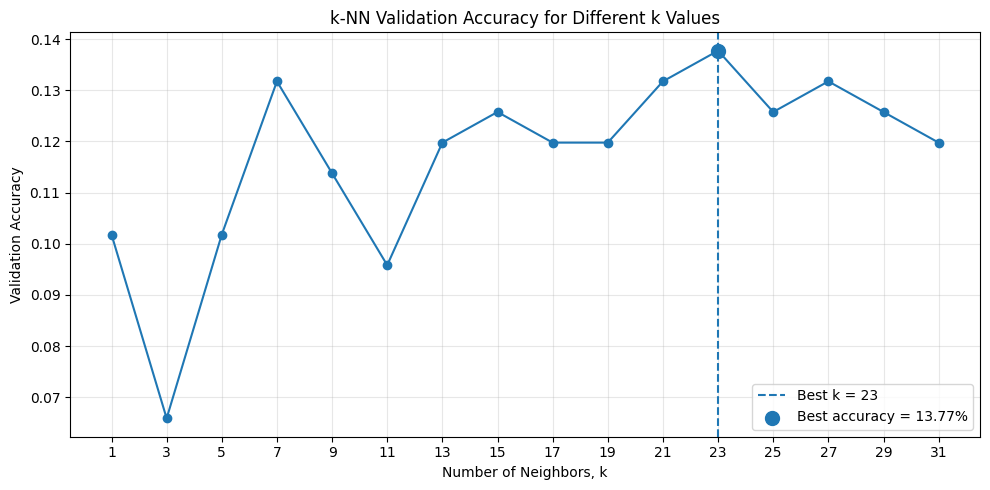

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    k_values,
    validation_accuracies,
    marker="o"
)

plt.axvline(
    best_k,
    linestyle="--",
    label=f"Best k = {best_k}"
)

plt.scatter(
    best_k,
    best_validation_accuracy,
    s=100,
    label=(
        f"Best accuracy = "
        f"{best_validation_accuracy * 100:.2f}%"
    )
)

plt.xlabel("Number of Neighbors, k")
plt.ylabel("Validation Accuracy")
plt.title("k-NN Validation Accuracy for Different k Values")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
best_knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="uniform",
    metric="euclidean",
    n_jobs=-1
)

best_knn_model.fit(
    X_train_scaled,
    y_train
)

best_validation_predictions = (
    best_knn_model.predict(X_val_scaled)
)

selected_model_accuracy = accuracy_score(
    y_val,
    best_validation_predictions
)

print("Selected k-NN model trained successfully.")
print("Selected k:", best_k)
print(
    f"Validation accuracy: "
    f"{selected_model_accuracy:.4f} "
    f"({selected_model_accuracy * 100:.2f}%)"
)

Selected k-NN model trained successfully.
Selected k: 23
Validation accuracy: 0.1377 (13.77%)


### Best-k Selection Conclusion

Different odd values of k from 1 to 31 were evaluated using the validation set. The value producing the highest validation accuracy was selected as the best k. The independent test set was not used during this selection process, preventing test-data leakage.
